In [1]:
import os
import glob
import json
import yaml
import numpy as np
import torch
import argparse
import pickle
import time
import tqdm
import sys
from pathlib import Path
abs_path = str(Path.cwd().parents[0].absolute())
sys.path+=[abs_path, f'{abs_path}/utils']
from evaluation import Options, Trainer

import trimesh
from utils.remesh_utils import ICT_face_model
from utils.arg_util import YamlArgParser
from utils.matplotlib_rnd import (
    render_mesh_diff,
    plot_image_array
)

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


In [2]:
## load checkpoint from originial NFR

ckpt = '' ## dummy ckpt
design='nfr'
dec_type = 'jacob'

config = f'{abs_path}/config/train.yml'
opts_yaml = yaml.load(open(config), Loader=yaml.FullLoader)
opts = argparse.Namespace(**opts_yaml)

opts.NFR = True
opts.dec_type = 'jacob'
opts.ckpt = '' ## ------> dummy ckpt
opts.design = 'nfr'

opts.device="cuda:0"

opts.data_rand_trans=False
opts.data_rand_scale=False
opts.learn_rig_emb=False
opts.use_decimate = False
opts.stage1 = True
opts.stage2 = False
opts.stage22 = False
opts.scale_exp = 1.0
opts.load_rigformer = False

trainer = Trainer(opts)

Loading... pretrained NFR


(11248, 3)


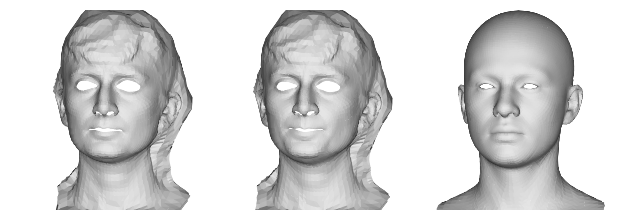

In [3]:
## full head
ict_face_model = ICT_face_model()
ict_tri = ict_face_model.get_mesh()

## flame
flame_tri = trimesh.load(f'{abs_path}/test-mesh/flame_final_transformed.obj', process=False, maintain_order=True)


## mf
with open(f"/data/sihun/pca/multiface_align/mf_templates.pkl",'rb') as f:
    mesh = pickle.load(f)
mesh_list = [idname for idname in mesh.keys() if idname!='face']
# mesh_v = mesh[mesh_list[-1]]
# mesh_v = mesh[mesh_list[2]]
mesh_v = mesh[mesh_list[-2]]
mf_tri=trimesh.Trimesh(vertices=mesh_v,faces=mesh['face'])
mesh_v = mesh[mesh_list[-1]]
mf_tri_test=trimesh.Trimesh(vertices=mesh_v,faces=mesh['face'])




paths_GT = sorted(glob.glob('/source/sihun/NeuralFacialAnimation/eval_CBD/GT-mf_ROM_test-to-mf_ROM_test/*.npy'))
src_mesh=mf_tri_test
# vertices = np.load(paths_GT[6638]).squeeze()[None]
vertices = np.stack([np.load(npy_path).squeeze() for npy_path in paths_GT])
# # vertices=vertices[6000:7000]
# # vertices = np.load(paths_GT[8404]).squeeze()
tgt_mesh = ict_tri



## ICT random expression
bs_coeff = np.eye(53)[26]

## ICT load animation capture
# vertices = torch.from_numpy(ict_tri.vertices + ict_face_model.get_exp_disp(bs_coeff))
# paths_GT = sorted(glob('/source/sihun/NeuralFacialAnimation/eval_CBD/GT-ict-cap_test-to-ict-cap_test_00/*.npy'))
# paths_GT = sorted(glob('/source/sihun/NeuralFacialAnimation/eval_CBD/GT-ict-cap_test-to-ict-cap_test_01/*.npy'))
# vertices = np.stack([np.load(npy_path).squeeze() for npy_path in paths_GT])
# src_mesh.vertices=vertices[0]

# # anim_coeffs = np.load('/source/sihun/NeuralFacialAnimation/_cap/20240318_MySlate_922_exp_coeffs.npy')
# anim_coeffs = np.load('/source/sihun/NeuralFacialAnimation/_cap/20240325_MySlate_924_exp_coeffs.npy')
# vertices = np.stack([
#     ict_tri.vertices+ict_face_model.get_exp_disp(anim_coeff).squeeze() for anim_coeff in anim_coeffs
# ])
# print(f"animation length: {vertices.shape[0]}")

# src_mesh = ict_tri
# # tgt_mesh = flame_tri
# tgt_mesh = mf_tri_test



print(ict_tri.vertices.shape)

M_SCALE = 0.68
v_list=[ src_mesh.vertices * M_SCALE, vertices[0] * M_SCALE, tgt_mesh.vertices * M_SCALE ]
f_list=[ src_mesh.faces, src_mesh.faces, tgt_mesh.faces ]
SIZE=2

plot_image_array(
    v_list, f_list,
    rot_list=[[0,-10,0]]*len(v_list), 
    size=SIZE, bg_black=False, mode='shade', 
    logdir=f"_tmp/train", 
    name=f"test", save=False
)

In [4]:
import time
from datetime import timedelta

st = time.time()

pred_outputs = trainer.model.inference(
    vertices=torch.from_numpy(vertices), 
    src_mesh=src_mesh, 
    tgt_mesh=tgt_mesh
)

td = timedelta(seconds=time.time() - st)
print(f"[Infer] computation time: {td}")

100%|██████████| 11649/11649 [17:08<00:00, 11.33it/s]


[Infer] computation time: 0:17:24.972632


 source neutral 	|	 source expression 	|	 target neutral 	|	 target expression


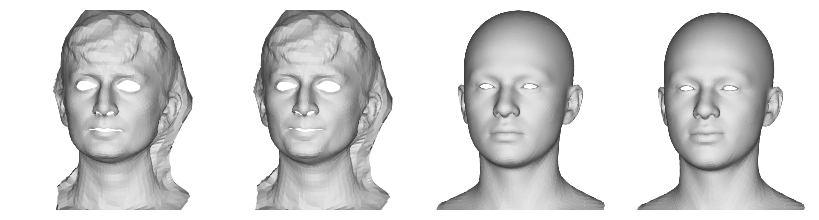

In [5]:
v_list=[
    src_mesh.vertices * M_SCALE,
    vertices[0] * M_SCALE,
    tgt_mesh.vertices * M_SCALE,
    pred_outputs.detach().cpu().numpy()[0] * M_SCALE
]
f_list=[
    src_mesh.faces,
    src_mesh.faces,    
    tgt_mesh.faces,
    tgt_mesh.faces
]

print(' source neutral \t|\t source expression \t|\t target neutral \t|\t target expression')
plot_image_array(
    v_list, f_list,
    rot_list=[[0,-10,0]]*len(v_list), 
    size=SIZE, bg_black=False, mode='shade', 
    logdir=f"_tmp/train", 
    name=f"test", save=False
)